# HyperMap: when is the embedding *meaningful*?

HyperMap is a **model-based** embedder: it assumes the graph was produced by the
E-PSO / hyperbolic model, and it infers the node coordinates that make that model
most likely. The model has two structural signatures:

1. a **power-law degree distribution** $P(k)\sim k^{-\gamma}$, and
2. **strong clustering** (many triangles).

When a graph carries these signatures, the fitted model is a faithful *generative*
description of it and its parameters ($\gamma$, $T$) are meaningful. When it does
not, the embedding may still place the nodes, but the model is the wrong lens.

We make this concrete by contrasting two graphs:

* a **balanced tree** — *not* power-law, and with **zero** clustering, and
* a **clustered power-law graph** (`powerlaw_cluster_graph`) — the regime the
  model was built for.

In [1]:
# !pip install git+https://github.com/cicadaUY/hypeGRL
import warnings
warnings.filterwarnings("ignore")

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from hypegrl.embedders.hypermap import HyperMapEmbedder
from hypegrl.inference.parameters import estimate_gamma, power_law_gof
from hypegrl.visualization import plot_polar

rng = np.random.default_rng(0)

## Two graphs

The tree is a complete binary tree of depth 7 (255 nodes). The positive example is
Holme–Kim's `powerlaw_cluster_graph`, which grows a Barabási–Albert-style scale-free
network while explicitly closing triangles, so it has *both* a power-law degree tail
*and* substantial clustering — unlike plain Barabási–Albert, which is nearly
triangle-free.

In [2]:
tree = nx.convert_node_labels_to_integers(nx.balanced_tree(2, 7))
plc  = nx.convert_node_labels_to_integers(
    nx.powerlaw_cluster_graph(400, 3, 0.9, seed=1)
)

for name, G in [("balanced tree", tree), ("powerlaw-cluster", plc)]:
    print(f"{name:18s} N={G.number_of_nodes():>4}  E={G.number_of_edges():>4}  "
          f"clustering(transitivity)={nx.transitivity(G):.3f}")

balanced tree      N= 255  E= 254  clustering(transitivity)=0.000
powerlaw-cluster   N= 400  E=1191  clustering(transitivity)=0.160


## Step 1 — check the modelling assumption *before* embedding

The single cheapest pre-check is the degree distribution: does a power law even fit?
`power_law_gof` runs the Clauset–Shalizi–Newman bootstrap test (small $p$ **rejects**
the power law), and `estimate_gamma` returns the maximum-likelihood exponent (or a
neutral fallback when no power law can be fit).

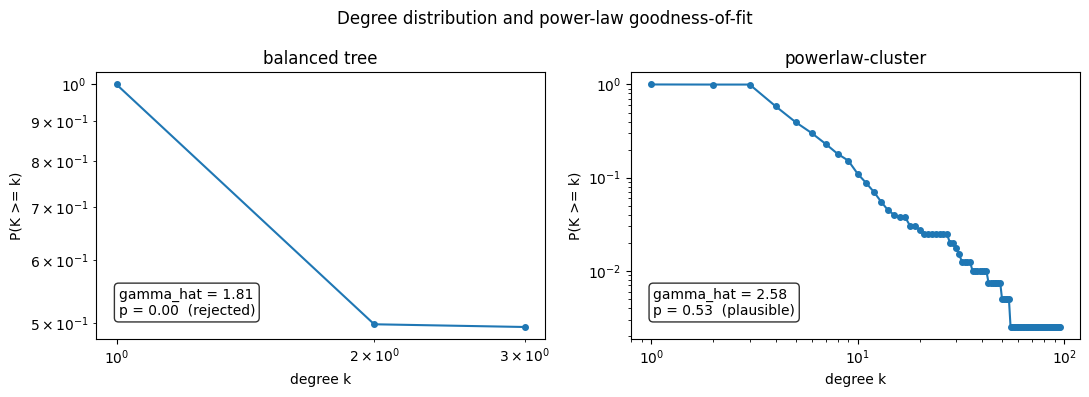

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, G) in zip(axes, [("balanced tree", tree),
                                 ("powerlaw-cluster", plc)]):
    degrees = np.array([d for _, d in G.degree()])
    gamma, _ = estimate_gamma(G)
    gof = power_law_gof(degrees, n_bootstrap=500, seed=0)
    p = gof["p_value"] if gof is not None else float("nan")

    # empirical complementary CDF (log-log)
    vals = np.arange(1, degrees.max() + 1)
    ccdf = np.array([(degrees >= k).mean() for k in vals])
    ax.loglog(vals, ccdf, "o-", ms=4)
    ax.set(xlabel="degree k", ylabel="P(K >= k)", title=name)
    verdict = "plausible" if (gof and gof["plausible"]) else "rejected"
    ax.text(0.05, 0.08,
            f"gamma_hat = {gamma:.2f}\np = {p:.2f}  ({verdict})",
            transform=ax.transAxes, va="bottom",
            bbox=dict(boxstyle="round", fc="w", alpha=0.8))
fig.suptitle("Degree distribution and power-law goodness-of-fit")
fig.tight_layout()
plt.show()

The tree's degree distribution is **rejected** as a power law ($p\approx 0$): it
piles up at degree 1 (leaves) and 3 (internal nodes), so the estimated $\gamma$ is
meaningless. The clustered power-law graph is judged **plausible** with a valid
$\gamma \in (2,3)$. Already at this stage HyperMap's $\gamma$ parameter is only
meaningful for the second graph.

## Step 2 — fit HyperMap and test *generative fidelity*

Now we embed both graphs and ask the model-based question: if we **sample new graphs
from the fitted model** (Bernoulli draws from the decoder's connection
probabilities), do they look like the original? We compare clustering — the property
the hyperbolic model is really about.

In [4]:
def fit_hypermap(G):
    emb = HyperMapEmbedder(d=2, T=0.5, n_steps=100, log_every=0,
                           verbose_init=False)
    emb.fit(G)
    return emb

def model_clustering(emb, n_samples=5):
    """Mean transitivity of graphs sampled from the fitted decoder."""
    P = emb.decode(emb.embeddings())
    N = P.shape[0]
    out = []
    for _ in range(n_samples):
        A = (rng.random((N, N)) < P).astype(int)
        A = np.triu(A, 1)
        out.append(nx.transitivity(nx.from_numpy_array(A + A.T)))
    return float(np.mean(out))

emb_tree = fit_hypermap(tree)
emb_plc  = fit_hypermap(plc)

rows = []
for name, G, emb in [("balanced tree", tree, emb_tree),
                     ("powerlaw-cluster", plc, emb_plc)]:
    rows.append((name, nx.transitivity(G), model_clustering(emb)))
    print(f"{name:18s} clustering: original={rows[-1][1]:.3f}  "
          f"model-generated={rows[-1][2]:.3f}")

balanced tree      clustering: original=0.000  model-generated=0.167
powerlaw-cluster   clustering: original=0.160  model-generated=0.141


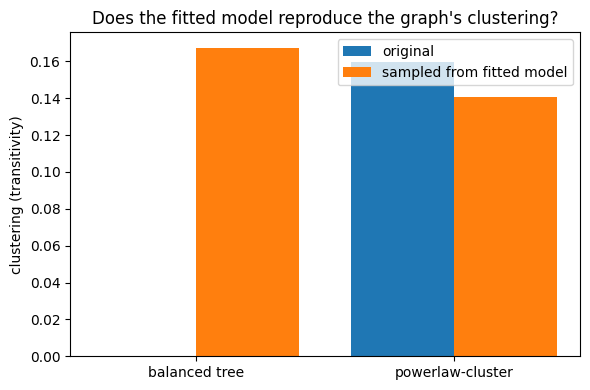

In [5]:
labels = [r[0] for r in rows]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - 0.2, [r[1] for r in rows], 0.4, label="original")
ax.bar(x + 0.2, [r[2] for r in rows], 0.4, label="sampled from fitted model")
ax.set(xticks=x, ylabel="clustering (transitivity)",
       title="Does the fitted model reproduce the graph's clustering?")
ax.set_xticklabels(labels)
ax.legend()
fig.tight_layout()
plt.show()

This is the crux. The model **cannot represent the tree**: the tree has clustering
$0$, but graphs sampled from its fitted model are full of triangles
($\approx 0.17$) — the hyperbolic model places connected nodes close together, and
close nodes form triangles, which a tree forbids. For the clustered power-law graph
the sampled clustering closely matches the original: the model is a faithful
description.

## Step 3 — the embeddings themselves

Finally we draw both embeddings in the **native polar** representation (angle = the
similarity coordinate, radius = the hyperbolic radius), which makes the degree
hierarchy easy to read: high-degree nodes sit near the centre, low-degree nodes near
the rim. HyperMap orders its rows by degree (`nodes_sorted`), **not** `G.nodes()`
order, so we pass that order to `plot_polar` via its `nodes=` argument. (Omit it and
the plot is silently scrambled — a common gotcha.)

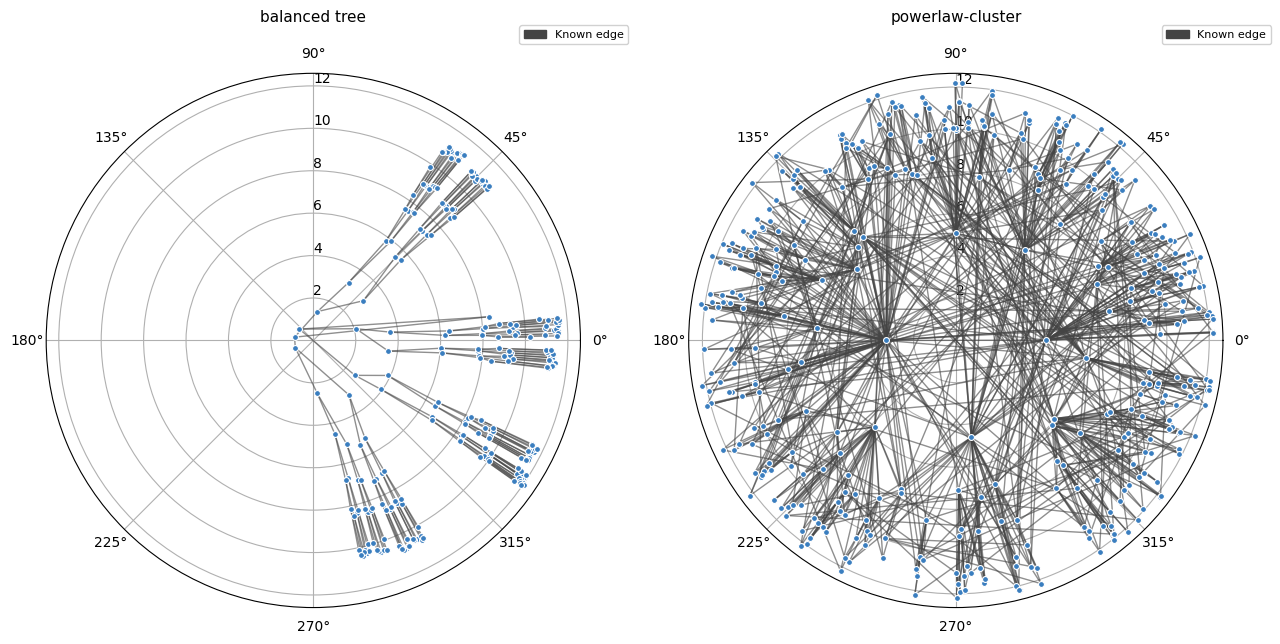

In [6]:
def plot_embedding(G, emb, title, ax):
    # HyperMap rows follow nodes_sorted; `nodes=` lets the plotter align them.
    plot_polar(G, emb.embeddings(), nodes=emb.nodes_sorted,
               show_node_labels=False, node_size=18, ax=ax, title=title)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5),
                         subplot_kw={"projection": "polar"})
plot_embedding(tree, emb_tree, "balanced tree", axes[0])
plot_embedding(plc, emb_plc, "powerlaw-cluster", axes[1])
fig.tight_layout()
plt.show()

Both are laid out sensibly — high-degree nodes near the centre, low-degree nodes
near the rim, with the tree's branches fanning outward. The tree is in fact placed
*cleanly*: its edge/non-edge separation is near-perfect, because trees are the
natural inhabitants of hyperbolic space. What fails for the tree is not the
*placement* but the **model** — its parameters and the structure it generates do not
match the graph, as Steps 1–2 showed.

## Step 4 — calibrating the temperature (optional)

`estimate_temperature` reads the temperature $T$ off a fitted embedding by matching
the Fermi–Dirac connection-probability slope. It calibrates the decoder (the
probability *values*, and any generation); it does not move the coordinates. It is
only meaningful where the model is — i.e. for the power-law graph.

In [7]:
print(f"powerlaw-cluster  T_hat = {emb_plc.estimate_temperature():.3f}")
print(f"balanced tree     T_hat = {emb_tree.estimate_temperature():.3f}  "
      f"(reported, but the model does not describe a tree)")

powerlaw-cluster  T_hat = 0.531
balanced tree     T_hat = 0.371  (reported, but the model does not describe a tree)


## Takeaways

* HyperMap is a **generative-model** embedder. "Reasonable results" means the fitted
  model *describes* the graph — not merely that nodes are placed.
* **Pre-check the assumption.** `power_law_gof` / `estimate_gamma` tell you whether a
  power law even fits. A tree is rejected; its $\gamma$ is meaningless.
* **Check generative fidelity.** Sampling from the decoder and comparing clustering
  exposes the tree's incompatibility (model clustering $\gg 0$) while confirming the
  power-law graph (model clustering $\approx$ original).
* A tree still *embeds* well geometrically — hyperbolic space is tree-like — so use
  a model-fit criterion, not reconstruction accuracy, to judge whether HyperMap is
  the right tool for a given graph.